# Week 2 - #04 Deep Learning for NLP

[Deep Learning Book](https://www.deeplearningbook.org/) -
[Tensor Flow Tutorial](https://www.tensorflow.org/tutorials)

- Hidden layer
- Perceptron
- Memory based learning
- Gradient descent
- Loss function

## Assignment

Build a simple neural network for text classification and report the training process and results.

Dataset: [A Large-scale Vietnamese News Text Classification Corpus](https://github.com/duyvuleo/VNTC)

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

## Load Dataset

In [3]:
!git clone https://github.com/duyvuleo/VNTC.git

Cloning into 'VNTC'...
remote: Enumerating objects: 39, done.
remote: Total 39 (delta 0), reused 0 (delta 0), pack-reused 39 (from 1)
Receiving objects: 100% (39/39), 160.90 MiB | 48.54 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (15/15), done.
Filtering content: 100% (2/2), 168.95 MiB | 56.10 MiB/s, done.


In [4]:
# extract rar files
%cd /kaggle/working/VNTC/Data/27Topics/Ver1.1
!unrar x -inul Train.rar
!unrar x -inul Test.rar

/kaggle/working/VNTC/Data/27Topics/Ver1.1


In [5]:
!ls "/kaggle/working/VNTC/Data/27Topics/Ver1.1/new train"

'Am nhac'	    'Duong vao WTO'	  'Lam dep'
'Am thuc'	    'Gia dinh'		  'Loi song'
'Bat dong san'	    'Giai tri tin hoc'	  'Mua sam'
'Bong da'	    'Giao duc'		  'My thuat'
'Chung khoan'	    'Gioi tinh'		  'San khau dien anh'
'Cum ga'	    'Hackers va Virus'	  'San pham tin hoc moi'
'Cuoc song do day'  'Hinh su'		   Tennis
'Du hoc'	    'Khong gian song'	  'The gioi tre'
'Du lich'	    'Kinh doanh quoc te'  'Thoi trang'


In [6]:
!ls "/kaggle/working/VNTC/Data/27Topics/Ver1.1/new test"

'Am nhac'	    'Duong vao WTO'	  'Lam dep'
'Am thuc'	    'Gia dinh'		  'Loi song'
'Bat dong san'	    'Giai tri tin hoc'	  'Mua sam'
'Bong da'	    'Giao duc'		  'My thuat'
'Chung khoan'	    'Gioi tinh'		  'San khau dien anh'
'Cum ga'	    'Hackers va Virus'	  'San pham tin hoc moi'
'Cuoc song do day'  'Hinh su'		   Tennis
'Du hoc'	    'Khong gian song'	  'The gioi tre'
'Du lich'	    'Kinh doanh quoc te'  'Thoi trang'


## Preprocessing Data

In [7]:
TRAIN_DIR = '/kaggle/working/VNTC/Data/27Topics/Ver1.1/new train'
TEST_DIR = '/kaggle/working/VNTC/Data/27Topics/Ver1.1/new test'

In [8]:
X_train_raw, y_train_raw, X_test_raw, y_test_raw = [], [], [], []

for dir in os.listdir(TRAIN_DIR):
  if os.path.isdir(os.path.join(TRAIN_DIR, dir)):
    for file in os.listdir(os.path.join(TRAIN_DIR, dir)):
      with open(os.path.join(TRAIN_DIR, dir, file), 'r', encoding='utf-16') as f:
        X_train_raw.append(f.read())
        y_train_raw.append(dir)

for dir in os.listdir(TEST_DIR):
  if os.path.isdir(os.path.join(TEST_DIR, dir)):
    for file in os.listdir(os.path.join(TEST_DIR, dir)):
      with open(os.path.join(TEST_DIR, dir, file), 'r', encoding='utf-16') as f:
        X_test_raw.append(f.read())
        y_test_raw.append(dir)

In [9]:
print(X_train_raw[0])

Bí mật của chàng
Phần lớn phụ nữ đều cho rằng họ rất hiểu người bạn đời của mình, song sự thật chưa hẳn vậy. Hãy nghe những lời tâm sự của đấng mày râu:
1. Nhạy cảm
Một số người cho rằng họ khó chấp nhận những thất bại dù là nhỏ nhất. Những lúc như thế, đàn ông cần được quan tâm, chia sẻ nhiều hơn.
2. Hay ghen
Cánh đàn ông ít ai tỏ vẻ mình có tính hay ghen nhưng sự thật thì lại khác. Chẳng hạn, khi đang đi dạo cùng người yêu, nếu nàng mỉm cười với một gã nào đó thì lập tức chàng chỉ muốn lao vào nện cho hắn một trận.
3. Nhiều khát vọng
Các chàng thường nung nấu những khát vọng. Trong công việc, họ luôn muốn mình là người giỏi nhất, uy tín nhất. Khi có cơ hội thể hiện, họ đều cố gắng tận dụng và bộc lộ tất cả khả năng của mình.
4. Là một đứa trẻ lớn
Họ sẵn lòng vui đùa cùng các con và trông nom chúng khéo ra trò. Có điều, từ khi đứa con chào đời hình như vợ chẳng thèm quan tâm đến chàng nữa.
5. Tìm bạn trong người bạn đời
Cái mà các chàng muốn nhất trong hôn nhân là sự đồng cảm, chia sẻ

In [10]:
print(X_test_raw[0])

 Cắt giảm chi phí trong 1 tháng Cuối tháng, cầm những hóa đơn thanh toán điện, nước, điện thoại, thực phẩm... trên tay, bạn thấy choáng. Những con số cứ nhảy “lam-ba-da” trước mặt bạn. Và bạn chỉ có thể thốt lên “Ôi, sao mà nhiều thế này!”
Tại sao có chuyện như thế ư? Đơn giản là vì bạn chi tiêu quá mức cần thiết. 
Với những khoản nhỏ vài nghìn đồng, bạn cứ phung phí hết cỡ. Nhưng bạn có biết, hàng chục lần của mấy nghìn đồng, con số tiền triệu có thể đi vèo như chơi. 
Vậy để khỏi phải chóng mặt vào cuối tháng, bạn hãy tìm cách cắt giảm một nửa chi phí trong một tháng. Có 6 cách cho bạn đây! 
1. Lên kế hoạch mua sắm trong tháng: 
Trong bản kế hoạch này, bạn đừng quên liệt kê tất cả những khoản mình đã chi tháng vừa rồi. Nhớ ghi chính xác từng chi tiết và từng đồng tiền lẻ một. Sau đó, bạn tính tổng số tiền đã xuất hầu bao. 
Tiếp theo, dựa trên danh mục những khoản chi cũ, bạn lên kế hoạch mua sắm cho tháng sắp tới, chỉ bằng một nửa số tiền ấy. 
Ghi nhớ: Phải tính toán từng khoản chi nh

In [11]:
print(f"Number of topic types in Train set: {len(np.unique(y_train_raw))}")
print(f"Number of topic types in Test set: {len(np.unique(y_test_raw))}")
print(np.unique(y_test_raw))

Number of topic types in Train set: 27
Number of topic types in Test set: 27
['Am nhac' 'Am thuc' 'Bat dong san' 'Bong da' 'Chung khoan' 'Cum ga'
 'Cuoc song do day' 'Du hoc' 'Du lich' 'Duong vao WTO' 'Gia dinh'
 'Giai tri tin hoc' 'Giao duc' 'Gioi tinh' 'Hackers va Virus' 'Hinh su'
 'Khong gian song' 'Kinh doanh quoc te' 'Lam dep' 'Loi song' 'Mua sam'
 'My thuat' 'San khau dien anh' 'San pham tin hoc moi' 'Tennis'
 'The gioi tre' 'Thoi trang']


In [12]:
print(f"Train size: {len(X_train_raw), len(y_train_raw)}")
print(f"Test size: {len(X_test_raw), len(y_test_raw)}")

Train size: (14375, 14375)
Test size: (12076, 12076)


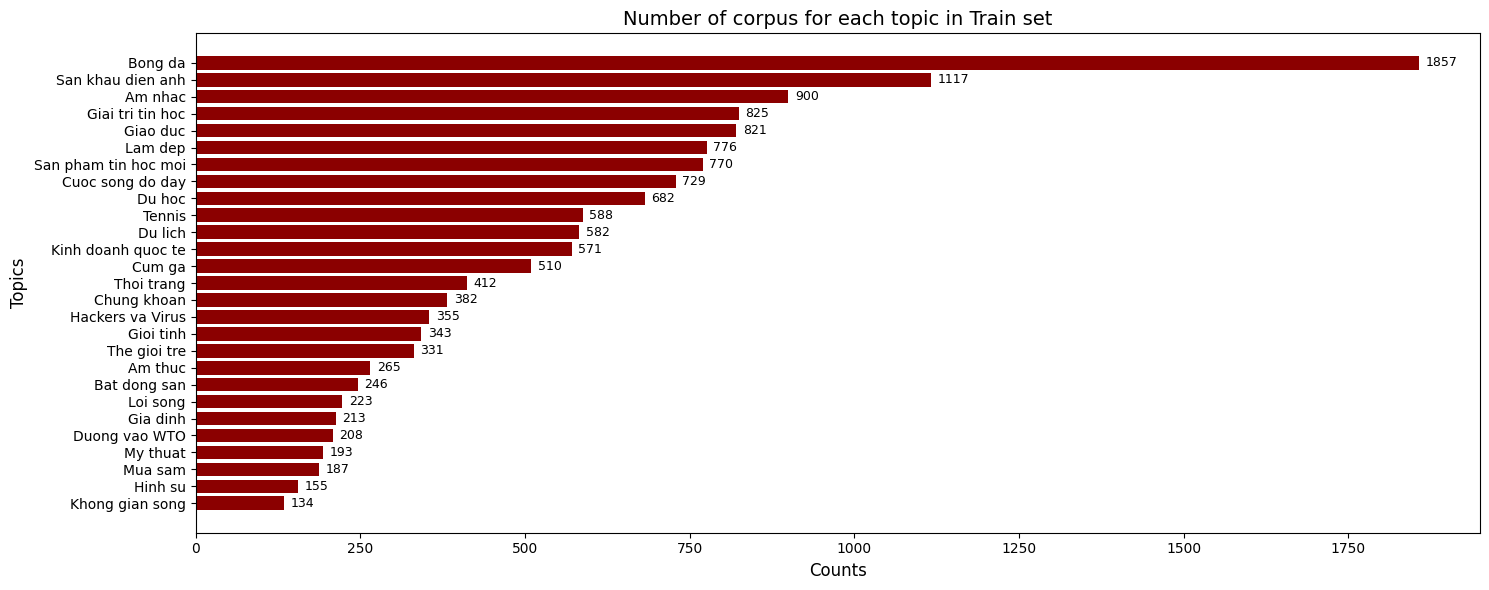

In [13]:
topics, counts = np.unique(y_train_raw, return_counts=True)
df = pd.DataFrame(counts, topics, columns=['counts'])
df = df.sort_values(by='counts', ascending=True)
plt.figure(figsize=(15,6))
bars = plt.barh(df.index, df['counts'], color='darkred')

# Add values on top of bars
for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 10, bar.get_y() + bar.get_height()/2, str(xval), va='center', fontsize=9)

plt.title("Number of corpus for each topic in Train set", fontsize=14)
plt.xlabel("Counts", fontsize=12)
plt.ylabel("Topics", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
len(" ".join(X_train_raw))

34881654

In [15]:
def normalize(text):
  text = text.lower()

  # remove html tag
  text = re.sub(r'<[^>]*>', '', text)
  # remove punctuation
  text = re.sub(r'[^\w\s]', ' ', text)
  # remove end line
  text = re.sub(r'\n', ' ', text)
  # remove extra white spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

In [16]:
X_train = [normalize(text) for text in X_train_raw]
X_test = [normalize(text) for text in X_test_raw]

In [17]:
X_train[0]

'bí mật của chàng phần lớn phụ nữ đều cho rằng họ rất hiểu người bạn đời của mình song sự thật chưa hẳn vậy hãy nghe những lời tâm sự của đấng mày râu 1 nhạy cảm một số người cho rằng họ khó chấp nhận những thất bại dù là nhỏ nhất những lúc như thế đàn ông cần được quan tâm chia sẻ nhiều hơn 2 hay ghen cánh đàn ông ít ai tỏ vẻ mình có tính hay ghen nhưng sự thật thì lại khác chẳng hạn khi đang đi dạo cùng người yêu nếu nàng mỉm cười với một gã nào đó thì lập tức chàng chỉ muốn lao vào nện cho hắn một trận 3 nhiều khát vọng các chàng thường nung nấu những khát vọng trong công việc họ luôn muốn mình là người giỏi nhất uy tín nhất khi có cơ hội thể hiện họ đều cố gắng tận dụng và bộc lộ tất cả khả năng của mình 4 là một đứa trẻ lớn họ sẵn lòng vui đùa cùng các con và trông nom chúng khéo ra trò có điều từ khi đứa con chào đời hình như vợ chẳng thèm quan tâm đến chàng nữa 5 tìm bạn trong người bạn đời cái mà các chàng muốn nhất trong hôn nhân là sự đồng cảm chia sẻ phải thú nhận rằng nếu a

In [18]:
len(" ".join(X_train))

33801554

## Train-Val Split

In [19]:
from sklearn.model_selection import train_test_split

X_train = np.array(X_train)
y_train_raw = np.array(y_train_raw)

# Split 80% train, 20% val, shuffle=True
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train_raw, test_size=0.1, random_state=42, stratify=y_train_raw
)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(12937,) (1438,)
(12937,) (1438,)


## Embedding

In [20]:
import torch
from transformers import AutoTokenizer, AutoModel

# Load PhoBERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(device)

# tokenization and embedding function using PhoBERT
def phobert_embedding(documents, tokenizer, model, max_len=256):
    embeddings = []
    for doc in documents:
        # Tokenize with attention_mask
        encoding = tokenizer(
            doc,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=max_len
        )
        device = 'cuda' if torch.cuda.is_available() else "cpu"
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            features = model(input_ids, attention_mask=attention_mask)

            # Mean pooling (remove [PAD] thanks to attention mask)
            last_hidden = features.last_hidden_state  # (1, seq_len, hidden_size)
            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
            sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
            mean_pooled = sum_embeddings / sum_mask

            embeddings.append(mean_pooled.squeeze().cpu().tolist())
    return embeddings

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [21]:
X_train_embeddings = phobert_embedding(X_train, tokenizer, phobert)
X_val_embeddings = phobert_embedding(X_val, tokenizer, phobert)
X_test_embeddings = phobert_embedding(X_test, tokenizer, phobert)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [22]:
X_train_embeddings = np.array(X_train_embeddings)
X_val_embeddings = np.array(X_val_embeddings)
X_test_embeddings = np.array(X_test_embeddings)

In [23]:
print(len(X_train_embeddings), len(X_train_embeddings[0]))

12937 768


In [24]:
# Save embedding vectors
%cd /kaggle/working
np.save("X_train_embeddings.npy", X_train_embeddings)
np.save("X_val_embeddings.npy", X_val_embeddings)
np.save("X_test_embeddings.npy", X_test_embeddings)

/kaggle/working


## Encode the topic labels as integer

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test_raw)

In [26]:
y_train_encoded

array([10,  3, 11, ..., 14,  5,  7])

In [27]:
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26])

In [28]:
np.unique(y_val_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26])

In [29]:
np.unique(y_test_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26])

In [30]:
np.save("y_train.npy", y_train_encoded)
np.save("y_val.npy", y_val_encoded)
np.save("y_test.npy", y_test_encoded)

## Build and Train Model

### Version: Tensor Flow

In [31]:
import tensorflow as tf

input_size = 768
num_classes = 27

model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_size,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model_tf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,827 (800.11 KB)

 Trainable params: 204,315 (798.11 KB)

 Non-trainable params: 512 (2.00 KB)

In [32]:
checkpoint_path = "best_mlp_model_tf.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]

In [33]:
history = model_tf.fit(
    X_train_embeddings, y_train_encoded,
    validation_data=(X_val_embeddings, y_val_encoded),
    batch_size=32,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1757579399.744948      80 service.cc:148] XLA service 0x7e5a4800cfd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757579399.745626      80 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757579399.953196      80 cuda_dnn.cc:529] Loaded cuDNN version 90300


 72/405 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0781 - loss: 3.8471

I0000 00:00:1757579400.960833      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2697 - loss: 2.8203 - val_accuracy: 0.7615 - val_loss: 1.3019
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6654 - loss: 1.1607 - val_accuracy: 0.8261 - val_loss: 0.6157
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7502 - loss: 0.8573 - val_accuracy: 0.8491 - val_loss: 0.5024
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7947 - loss: 0.6993 - val_accuracy: 0.8644 - val_loss: 0.4448
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8119 - loss: 0.6302 - val_accuracy: 0.8658 - val_loss: 0.4092
Epoch 6/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8307 - loss: 0.5499 - val_accuracy: 0.8720 - val_loss: 0.3946
Epoch 7/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8448 - loss: 0.5121 - val_accuracy: 0.8797 - val_loss: 0.3793
Epoch 8/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8537 - loss: 0.4775 - val_accuracy: 0.8762 - val_

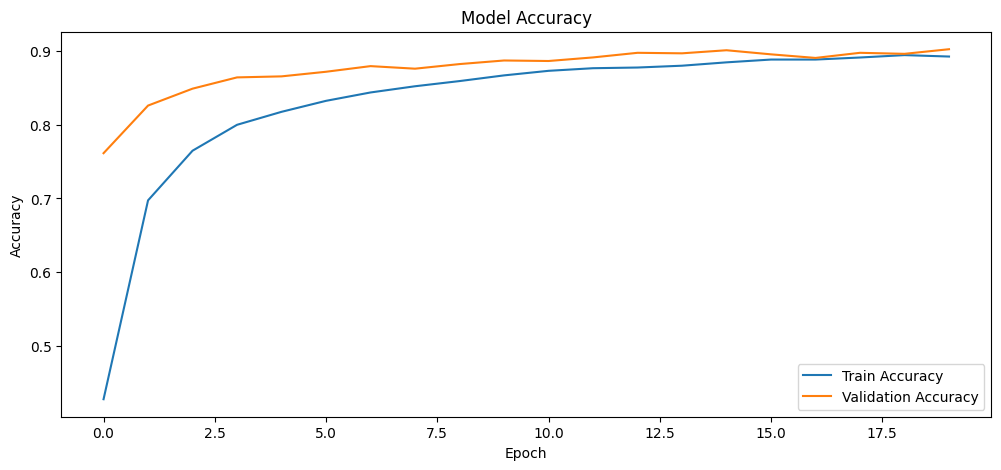

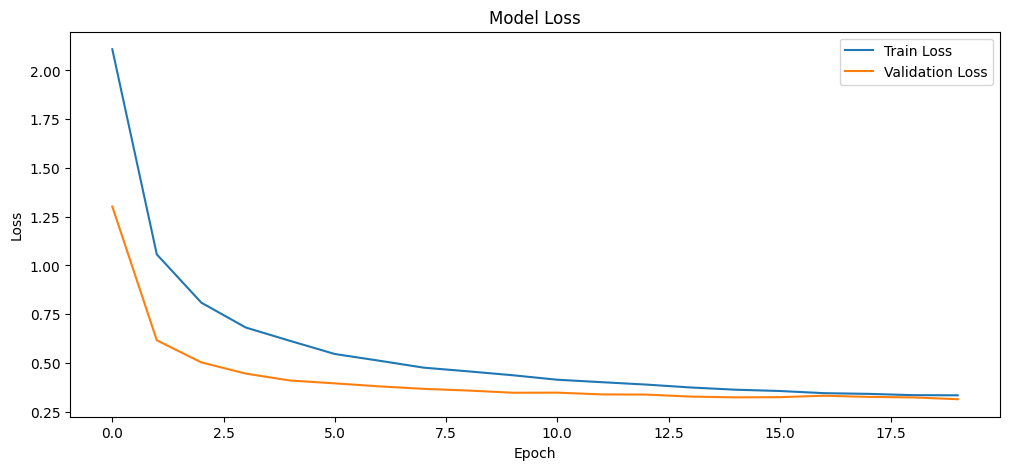

In [34]:
# Visualize training progress
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [47]:
from tensorflow import keras
loaded_model_tf = keras.models.load_model("best_mlp_model_tf.keras")

In [48]:
test_loss, test_acc = loaded_model_tf.evaluate(X_test_embeddings, y_test_encoded, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8547 - loss: 0.4459
Test loss: 0.4049
Test accuracy: 0.8645


In [49]:
y_pred_prob = loaded_model_tf.predict(X_test_embeddings)
y_pred = np.argmax(y_pred_prob, axis=1)
print(y_pred)

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[11 19 13 ... 22 22 22]


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

             Am nhac       0.88      0.90      0.89       813
             Am thuc       0.98      0.91      0.94       400
        Bat dong san       0.94      0.94      0.94       282
             Bong da       0.99      0.98      0.99      1464
         Chung khoan       0.95      0.93      0.94       320
              Cum ga       0.98      0.98      0.98       381
    Cuoc song do day       0.64      0.79      0.71       405
              Du hoc       0.95      0.87      0.91       394
             Du lich       0.89      0.91      0.90       565
       Duong vao WTO       0.90      0.70      0.79       191
            Gia dinh       0.78      0.47      0.59       280
    Giai tri tin hoc       0.67      0.83      0.74       707
            Giao duc       0.86      0.87      0.87       707
           Gioi tinh       0.80      0.88      0.84       268
    Hackers va Virus       0.95      0.79      0.87       319
       

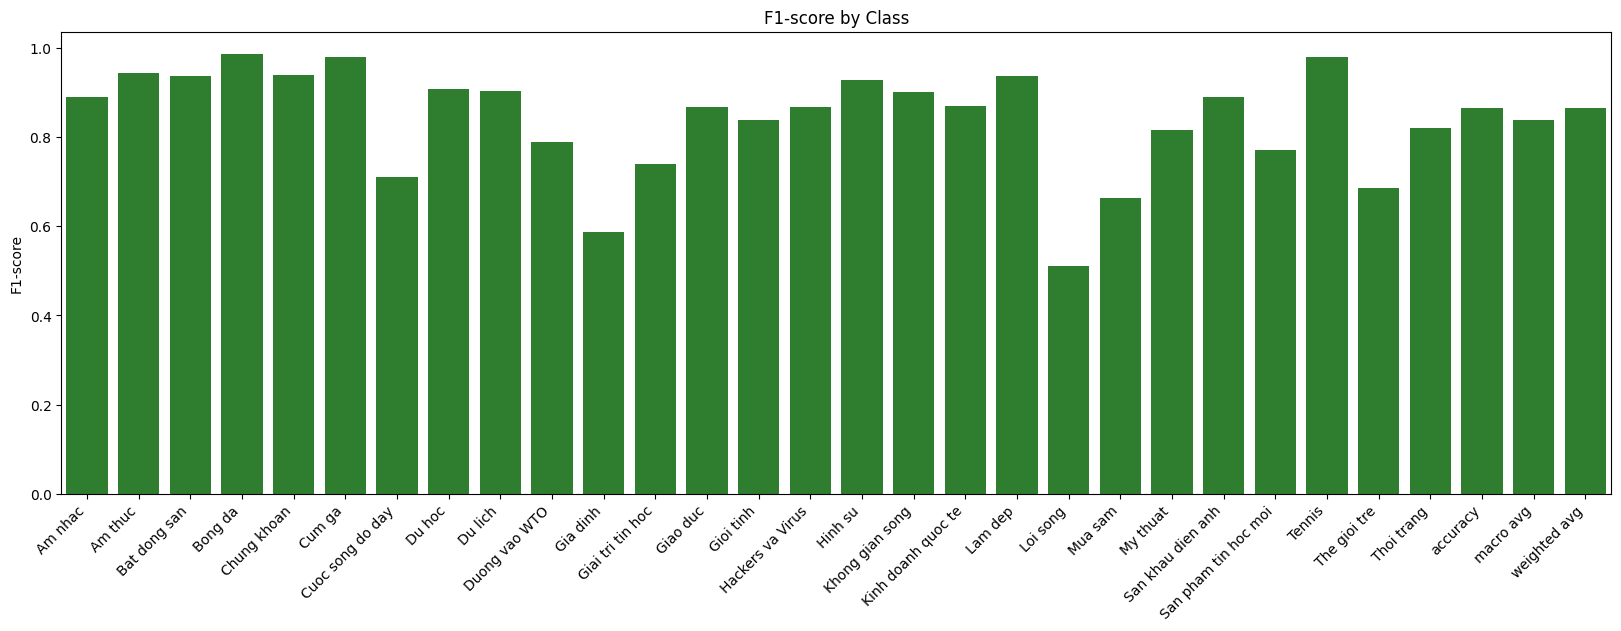

In [64]:
report = classification_report(
    y_test_encoded, y_pred, target_names=label_encoder.classes_, output_dict=True
)

df_report = pd.DataFrame(report).transpose()

# F1-score
plt.figure(figsize=(20, 6))
sns.barplot(x=df_report.index, y=df_report["f1-score"], color='forestgreen')
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("F1-score by Class")
plt.show()

### Version: Pytorch

#### DataLoader

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader, Dataset

BATCH_SIZE = 32
X_train_tensor = torch.tensor(X_train_embeddings, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_embeddings, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

#### Model

In [5]:
import torch.nn as nn
import torch.optim as optim

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.6),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

input_size = 768
num_classes = 27
model = MLPClassifier(input_dim=input_size, num_classes=num_classes).to(device)
print(model)

Using cuda device
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=27, bias=True)
  )
)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [7]:
from tqdm import tqdm

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    # tqdm progress bar
    loop = tqdm(dataloader, leave=False)
    for X, y in loop:
        X, y = X.to(device), y.to(device)

        # Forward
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item() * X.size(0)
        running_correct += (pred.argmax(1) == y).sum().item()
        running_total += y.size(0)

        acc = running_correct / running_total
        loop.set_description(f"Train")
        loop.set_postfix(loss=loss.item(), acc=acc*100)

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def evaluate(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            running_loss += loss_fn(pred, y).item() * X.size(0)
            running_correct += (pred.argmax(1) == y).sum().item()
            running_total += y.size(0)

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc

In [8]:
EPOCHS = 30
patience = 5
best_val_loss = float('inf')
checkpoint_path = "best_mlp_model_pytorch.pth"
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train(train_loader, model, criterion, optimizer)
    val_loss, val_acc = evaluate(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)
        early_stop_counter = 0
        print("Saved best model so far!")
    else:
        early_stop_counter += 1
        print(f"No improvement. Early stop counter = {early_stop_counter}/{patience}")
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/30


  Train Loss: 1.9410 | Train Acc: 0.4975
  Val   Loss: 1.0057 | Val   Acc: 0.7775
Saved best model so far!
Epoch 2/30


  Train Loss: 0.9948 | Train Acc: 0.7429
  Val   Loss: 0.6603 | Val   Acc: 0.8394
Saved best model so far!
Epoch 3/30


  Train Loss: 0.7459 | Train Acc: 0.8023
  Val   Loss: 0.5128 | Val   Acc: 0.8762
Saved best model so far!
Epoch 4/30


  Train Loss: 0.6193 | Train Acc: 0.8292
  Val   Loss: 0.4450 | Val   Acc: 0.8825
Saved best model so far!
Epoch 5/30


...

  Train Loss: 0.3329 | Train Acc: 0.8945
  Val   Loss: 0.3338 | Val   Acc: 0.8978
No improvement. Early stop counter = 1/5
Epoch 18/30


  Train Loss: 0.3251 | Train Acc: 0.8981
  Val   Loss: 0.3352 | Val   Acc: 0.8992
No improvement. Early stop counter = 2/5
Epoch 19/30


  Train Loss: 0.3233 | Train Acc: 0.8951
  Val   Loss: 0.3292 | Val   Acc: 0.8957
No improvement. Early stop counter = 3/5
Epoch 20/30


  Train Loss: 0.3248 | Train Acc: 0.8976
  Val   Loss: 0.3284 | Val   Acc: 0.8964
No improvement. Early stop counter = 4/5
Epoch 21/30


  Train Loss: 0.3009 | Train Acc: 0.9002
  Val   Loss: 0.3366 | Val   Acc: 0.8978
No improvement. Early stop counter = 5/5
Early stopping triggered.


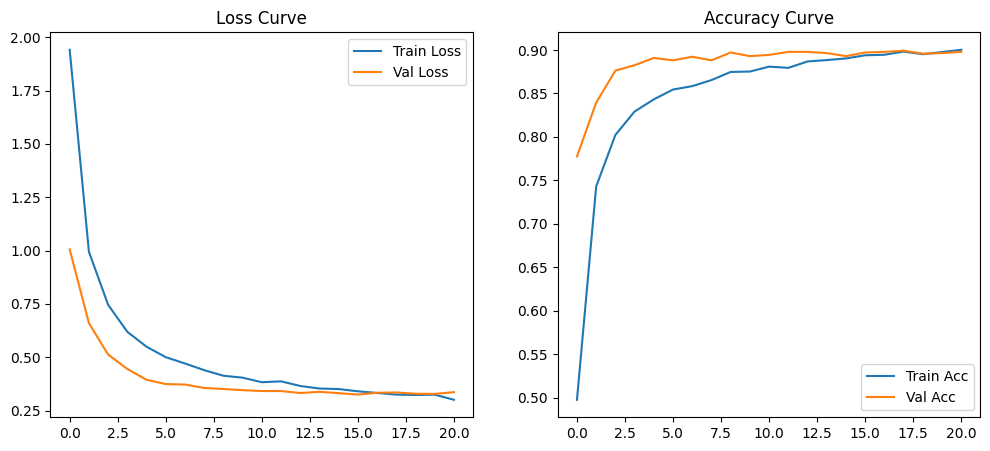

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.legend(); plt.title("Accuracy Curve")
plt.show()